In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("hyderabad_water_merged_v5.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(4187, 18)
['year', 'month', 'section', 'division', 'noofbookings', 'delivered', 'applied', 'approved', 'collection', 'demand', 'noofcans', 'latitude', 'longitude', 'gwl_mean', 'gwl_min', 'gwl_max', 'nearby_water_body_count', 'nearby_water_spread_total']


,year,month,section,division,noofbookings,delivered,applied,approved,collection,demand,noofcans,latitude,longitude,gwl_mean,gwl_min,gwl_max,nearby_water_body_count,nearby_water_spread_total
0,2022,1,ADARSHNAGAR,12,6,6,1.0,0.0,11299865.84,18869368.12,5883.0,17.404547,78.473584,-4.225103,-6.030,25.278,4,1356.972184
1,2022,1,ADIKMET,5,81,81,3.0,0.0,806258.06,9867096.65,2931.0,17.409550,78.513094,-6.672932,-12.052,1.000,8,85.540442
2,2022,1,AHMED NAGAR,3,7,7,4.0,0.0,11081.00,2868716.60,2906.0,17.404066,78.444229,-1.224051,-3.314,1.000,9,57.143820
3,2022,1,ALIABAD,33,1,1,8.0,3.0,104191.40,7206657.50,6411.0,17.345630,78.472680,-4.981352,-19.652,1.000,10,63.167633
4,2022,1,ALKAPURI,10,115,115,16.0,1.0,1088264.39,24713771.15,8320.0,17.366234,78.554978,-15.115934,-24.000,38.681,13,146.578046


In [2]:
df[["noofbookings", "delivered", "gwl_mean", "gwl_min", "demand", "collection", "applied", "approved", "nearby_water_body_count", "nearby_water_spread_total"]].corr()

,noofbookings,delivered,gwl_mean,gwl_min,demand,collection,applied,approved,nearby_water_body_count,nearby_water_spread_total
noofbookings,1.000000,0.999996,-0.073530,-0.003290,0.420208,0.372178,0.059261,0.006355,0.278638,-0.034364
delivered,0.999996,1.000000,-0.073588,-0.003349,0.420174,0.372174,0.059218,0.006372,0.278586,-0.034331
gwl_mean,-0.073530,-0.073588,1.000000,0.699215,0.007755,0.003956,0.020194,0.032374,-0.286796,0.088654
gwl_min,-0.003290,-0.003349,0.699215,1.000000,0.059639,0.055486,0.017891,0.021192,-0.270209,0.118251
demand,0.420208,0.420174,0.007755,0.059639,1.000000,0.587605,0.058321,0.006623,0.201460,0.007291
collection,0.372178,0.372174,0.003956,0.055486,0.587605,1.000000,0.132589,0.127703,0.151638,0.011816
applied,0.059261,0.059218,0.020194,0.017891,0.058321,0.132589,1.000000,0.899902,0.040339,0.168090
approved,0.006355,0.006372,0.032374,0.021192,0.006623,0.127703,0.899902,1.000000,0.002491,0.160126
nearby_water_body_count,0.278638,0.278586,-0.286796,-0.270209,0.201460,0.151638,0.040339,0.002491,1.000000,-0.079121
nearby_water_spread_total,-0.034364,-0.034331,0.088654,0.118251,0.007291,0.011816,0.168090,0.160126,-0.079121,1.000000


In [3]:
df["tanker_dependency"] = df["noofbookings"]
df["groundwater_depletion"] = df["gwl_min"]  # more negative = worse
df["unmet_connection_demand"] = df["applied"] - df["approved"]
df["billing_gap"] = df["demand"] - df["collection"]
df["water_body_scarcity"] = df["nearby_water_body_count"]  # fewer = worse, we'll invert during scoring

df[["tanker_dependency", "groundwater_depletion", "unmet_connection_demand", "billing_gap", "water_body_scarcity"]].describe()

,tanker_dependency,groundwater_depletion,unmet_connection_demand,billing_gap,water_body_scarcity
count,4187.000000,4187.000000,4085.000000,4.146000e+03,4187.000000
mean,307.277287,-21.313572,13.441371,3.801841e+06,12.854311
std,806.917702,19.520324,30.540404,8.164228e+06,6.954310
min,1.000000,-104.503000,0.000000,-1.493542e+08,0.000000
25%,15.000000,-24.000000,2.000000,1.000768e+06,7.000000
50%,76.000000,-15.772000,6.000000,2.059758e+06,13.000000
75%,224.000000,-8.085000,13.000000,4.268295e+06,17.000000
max,10037.000000,-1.670000,495.000000,4.789532e+07,29.000000


In [4]:
df["billing_gap_clipped"] = df["billing_gap"].clip(lower=0)
df["billing_gap_clipped"].describe()

count    4.146000e+03
mean     4.177443e+06
std      6.202592e+06
min      0.000000e+00
25%      1.000768e+06
50%      2.059758e+06
75%      4.268295e+06
max      4.789532e+07
Name: billing_gap_clipped, dtype: float64

In [5]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df["tanker_dependency_norm"] = normalize(df["tanker_dependency"])
df["unmet_connection_demand_norm"] = normalize(df["unmet_connection_demand"])
df["billing_gap_norm"] = normalize(df["billing_gap_clipped"])

# invert these two, since LOWER groundwater level / FEWER water bodies = worse
df["groundwater_depletion_norm"] = 1 - normalize(df["groundwater_depletion"])
df["water_body_scarcity_norm"] = 1 - normalize(df["water_body_scarcity"])

# verify the inversions worked correctly
worst_gw = df.loc[df["groundwater_depletion"].idxmin()]
print("Worst groundwater section:", worst_gw["section"], "| raw:", worst_gw["groundwater_depletion"], "| normalized (should be near 1):", worst_gw["groundwater_depletion_norm"])

worst_wb = df.loc[df["water_body_scarcity"].idxmin()]
print("Worst water body section:", worst_wb["section"], "| raw:", worst_wb["water_body_scarcity"], "| normalized (should be near 1):", worst_wb["water_body_scarcity_norm"])

Worst groundwater section: BHAGATSINGH NAGAR | raw: -104.503 | normalized (should be near 1): 1.0
Worst water body section: PATHANCHERU | raw: 0 | normalized (should be near 1): 1.0


In [6]:
weights = {
    "tanker_dependency_norm": 0.30,       # most direct, observable signal of current stress
    "groundwater_depletion_norm": 0.25,   # strong root-cause indicator
    "billing_gap_norm": 0.20,             # infrastructure/revenue health
    "unmet_connection_demand_norm": 0.15, # growth pressure signal
    "water_body_scarcity_norm": 0.10      # environmental buffer, more indirect
}

df["water_stress_score"] = sum(df[feature] * weight for feature, weight in weights.items())

print(df["water_stress_score"].describe())

count    4048.000000
mean        0.134450
std         0.058029
min         0.027421
25%         0.095386
50%         0.118425
75%         0.161885
max         0.443175
Name: water_stress_score, dtype: float64


In [7]:
print("Total rows:", len(df))
print("Rows with valid score:", df["water_stress_score"].notna().sum())
print("Rows with NaN score:", df["water_stress_score"].isna().sum())

# check which underlying feature has NaNs causing this
for col in ["tanker_dependency_norm", "groundwater_depletion_norm", "billing_gap_norm", "unmet_connection_demand_norm", "water_body_scarcity_norm"]:
    print(col, "-> NaN count:", df[col].isna().sum())

Total rows: 4187
Rows with valid score: 4048
Rows with NaN score: 139
tanker_dependency_norm -> NaN count: 0
groundwater_depletion_norm -> NaN count: 0
billing_gap_norm -> NaN count: 41
unmet_connection_demand_norm -> NaN count: 102
water_body_scarcity_norm -> NaN count: 0


In [8]:
score_features = ["tanker_dependency_norm", "groundwater_depletion_norm", "billing_gap_norm",
                   "unmet_connection_demand_norm", "water_body_scarcity_norm"]

for col in score_features:
    df[col] = df[col].fillna(0)  # treat missing as "no signal" rather than dropping the whole row

df["water_stress_score"] = sum(df[feature] * weight for feature, weight in weights.items())
print(df["water_stress_score"].describe())

count    4187.000000
mean        0.133833
std         0.057516
min         0.027421
25%         0.095364
50%         0.118143
75%         0.160457
max         0.443175
Name: water_stress_score, dtype: float64


In [9]:
# top 15 highest risk sections
print(df.groupby("section")["water_stress_score"].mean().sort_values(ascending=False).head(15))

print()

# bottom 15 lowest risk sections
print(df.groupby("section")["water_stress_score"].mean().sort_values(ascending=True).head(15))

section
PEDDA AMBERPET       0.316741
MADHAPUR             0.291382
HOUSING BOARD        0.288987
BHAGATSINGH NAGAR    0.264474
BANJARA HILLS        0.250687
VIVEKANANDA NAGAR    0.248944
DILSHUKNAGAR         0.241940
NALLAGANDLA          0.241430
KONDAPUR             0.234130
BACHUPALLY           0.233829
KPHB                 0.228211
SAROORNAGAR          0.227909
S.R.NAGAR            0.227486
DHAMMAIGUDA          0.224179
VENGALRAONAGAR       0.217121
Name: water_stress_score, dtype: float64

section
BOLLARAM            0.035020
THOOMKUNTA          0.048193
KATEDAN             0.056264
MAILERDEV PALLY     0.057598
BORABANDA           0.064202
KOMPALLY            0.064291
DEEPTHISRI NAGAR    0.069474
CHINTAL             0.070550
MEHIDIPATNAM        0.070886
ALWAL               0.071174
CHANDA NAGAR        0.071313
LALAPET             0.073299
TOLI CHOWK          0.077768
MOTI NAGAR          0.077827
SHAPOORNAGAR        0.079646
Name: water_stress_score, dtype: float64


In [10]:
for col in ["tanker_dependency_norm", "groundwater_depletion_norm", "billing_gap_norm", "unmet_connection_demand_norm", "water_body_scarcity_norm"]:
    print(col, df.groupby("section")[col].mean().corr(df.groupby("section")["water_stress_score"].mean()))

tanker_dependency_norm 0.39908887228662226
groundwater_depletion_norm 0.789687650044531
billing_gap_norm 0.3182664219288141
unmet_connection_demand_norm 0.15867206153314894
water_body_scarcity_norm 0.043494774158964265


In [11]:
for col in ["tanker_dependency_norm", "groundwater_depletion_norm", "billing_gap_norm", "unmet_connection_demand_norm", "water_body_scarcity_norm"]:
    print(col, df[col].std())

tanker_dependency_norm 0.08040232182360013
groundwater_depletion_norm 0.1898254844764242
billing_gap_norm 0.1291532499631833
unmet_connection_demand_norm 0.06108510876472675
water_body_scarcity_norm 0.23980379775487273


In [12]:
def zscore(series):
    return (series - series.mean()) / series.std()

df["tanker_dependency_z"] = zscore(df["tanker_dependency"])
df["groundwater_depletion_z"] = zscore(-df["groundwater_depletion"])  # negate first so higher=worse, then z-score
df["billing_gap_z"] = zscore(df["billing_gap"])
df["unmet_connection_demand_z"] = zscore(df["unmet_connection_demand"])
df["water_body_scarcity_z"] = zscore(-df["water_body_scarcity"])  # negate first so fewer=higher

df["water_stress_score_v2"] = (
    0.30 * df["tanker_dependency_z"] +
    0.25 * df["groundwater_depletion_z"] +
    0.20 * df["billing_gap_z"] +
    0.15 * df["unmet_connection_demand_z"] +
    0.10 * df["water_body_scarcity_z"]
)

print(df["water_stress_score_v2"].describe())

# re-check correlation of each feature with the NEW score
for col in ["tanker_dependency_z", "groundwater_depletion_z", "billing_gap_z", "unmet_connection_demand_z", "water_body_scarcity_z"]:
    print(col, df[col].corr(df["water_stress_score_v2"]))

count    4048.000000
mean        0.002883
std         0.462486
min        -3.624854
25%        -0.266727
50%        -0.143809
75%         0.193351
max         3.753834
Name: water_stress_score_v2, dtype: float64
tanker_dependency_z 0.6732770266500103
groundwater_depletion_z 0.4777403795058558
billing_gap_z 0.48562674462395633
unmet_connection_demand_z 0.3802368775474306
water_body_scarcity_z -0.16590710174733153


In [13]:
for col in ["tanker_dependency_z", "groundwater_depletion_z", "billing_gap_z", "unmet_connection_demand_z", "water_body_scarcity_z"]:
    df[col] = df[col].fillna(0)

df["water_stress_score_v2"] = (
    0.30 * df["tanker_dependency_z"] +
    0.25 * df["groundwater_depletion_z"] +
    0.20 * df["billing_gap_z"] +
    0.15 * df["unmet_connection_demand_z"] +
    0.10 * df["water_body_scarcity_z"]
)
print(df["water_stress_score_v2"].count())

4187


In [14]:
# top 15 highest risk sections
print(df.groupby("section")["water_stress_score_v2"].mean().sort_values(ascending=False).head(15))

print()

# bottom 15 lowest risk sections
print(df.groupby("section")["water_stress_score_v2"].mean().sort_values(ascending=True).head(15))

section
MADHAPUR             2.165163
KONDAPUR             1.687230
BANJARA HILLS        1.085107
HAFEEZPET            1.076862
PEDDA AMBERPET       0.970762
KPHB                 0.958285
JAWAHARNAGAR         0.866116
HOUSING BOARD        0.785730
NIZAMPET             0.699724
S.R.NAGAR            0.697010
BHAGATSINGH NAGAR    0.656105
VIVEKANANDA NAGAR    0.545882
NALLAGANDLA          0.526630
BACHUPALLY           0.500947
VENGALRAONAGAR       0.496603
Name: water_stress_score_v2, dtype: float64

section
KOMPALLY          -0.604803
THOOMKUNTA        -0.566642
BOLLARAM          -0.555624
KATEDAN           -0.456624
MAILERDEV PALLY   -0.429253
SHAMSHABAD        -0.411185
LALAPET           -0.401167
BORABANDA         -0.392372
AHMED NAGAR       -0.377500
MEHIDIPATNAM      -0.370580
ALWAL             -0.361016
TELLAPUR          -0.352319
CHINTAL           -0.351305
KARWAN            -0.343406
AMEENPUR          -0.341348
Name: water_stress_score_v2, dtype: float64


In [15]:
score_cols_z = ["tanker_dependency_z", "groundwater_depletion_z", "billing_gap_z",
                "unmet_connection_demand_z", "water_body_scarcity_z"]

for col in score_cols_z:
    df[col] = df[col].clip(-2, 2)   # cap extreme values so one feature can't dominate a single section

df["water_stress_score_v3"] = (
    0.30 * df["tanker_dependency_z"] +
    0.25 * df["groundwater_depletion_z"] +
    0.20 * df["billing_gap_z"] +
    0.15 * df["unmet_connection_demand_z"] +
    0.10 * df["water_body_scarcity_z"]
)

# check correlations to confirm no single feature dominates anymore
for col in score_cols_z:
    print(col, df[col].corr(df["water_stress_score_v3"]))

print()
print(df.groupby("section")["water_stress_score_v3"].mean().sort_values(ascending=False).head(15))

tanker_dependency_z 0.5721523028186818
groundwater_depletion_z 0.6530800335244585
billing_gap_z 0.462475749980117
unmet_connection_demand_z 0.3287495940485631
water_body_scarcity_z -0.08431724449882573

section
BANJARA HILLS        0.776149
MADHAPUR             0.717350
KPHB                 0.708108
NIZAMPET             0.589795
S.R.NAGAR            0.588848
HAFEEZPET            0.576914
KONDAPUR             0.545550
VIVEKANANDA NAGAR    0.493998
NALLAGANDLA          0.482717
SOMAJIGUDA           0.480405
SAROORNAGAR          0.477362
VENGALRAONAGAR       0.471159
YELLAREDDYGUDA       0.463437
DILSHUKNAGAR         0.457797
DHAMMAIGUDA          0.443902
Name: water_stress_score_v3, dtype: float64


In [16]:
sec = df.groupby("section").agg({
    "water_stress_score_v3": "mean",
    "latitude": "first",
    "longitude": "first"
}).reset_index()

mean, std = sec["water_stress_score_v3"].mean(), sec["water_stress_score_v3"].std()

def tier(score):
    if score > mean + 0.5*std:
        return "High"
    elif score < mean - 0.25*std:
        return "Low"
    else:
        return "Medium"

sec["risk_tier"] = sec["water_stress_score_v3"].apply(tier)
print(sec["risk_tier"].value_counts())

sec.to_csv("section_risk_scores_v3.csv", index=False)

risk_tier
Low       102
High       46
Medium     37
Name: count, dtype: int64


In [17]:
!pip install folium

In [18]:
import folium
import branca.colormap as cm

vmin, vmax = sec["water_stress_score_v3"].min(), sec["water_stress_score_v3"].max()
colormap = cm.LinearColormap(colors=["green", "yellow", "red"], vmin=vmin, vmax=vmax)

center_lat, center_lon = sec["latitude"].mean(), sec["longitude"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="cartodbpositron")

for _, row in sec.iterrows():
    color = colormap(row["water_stress_score_v3"])
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        popup=f"{row['section']}: {row['water_stress_score_v3']:.3f}",
        tooltip=row["section"],
        color=color, fill=True, fill_color=color, fill_opacity=0.9
    ).add_to(m)

colormap.caption = "Water Stress Score (continuous)"
colormap.add_to(m)
m.save("hyderabad_water_stress_map_gradient.html")

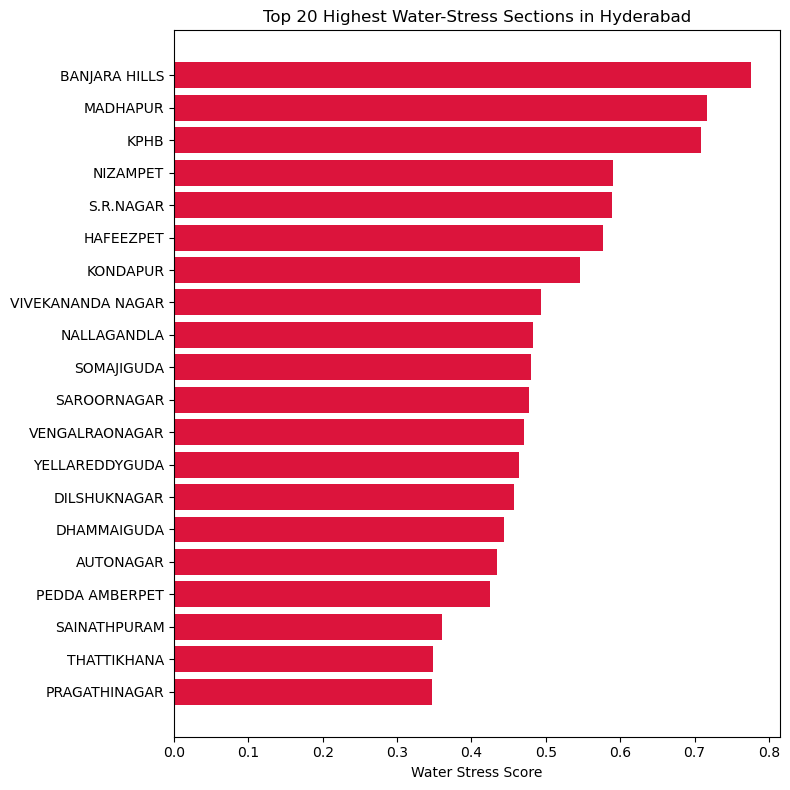

In [19]:
import matplotlib.pyplot as plt

top20 = sec.nlargest(20, "water_stress_score_v3").sort_values("water_stress_score_v3")

plt.figure(figsize=(8, 8))
plt.barh(top20["section"], top20["water_stress_score_v3"], color="crimson")
plt.xlabel("Water Stress Score")
plt.title("Top 20 Highest Water-Stress Sections in Hyderabad")
plt.tight_layout()
plt.savefig("top20_risk_chart.png")
plt.show()

In [20]:
!pip install libpysal
!pip install esda

In [21]:

import libpysal
from esda.moran import Moran

coords = sec[["longitude", "latitude"]].values
w = libpysal.weights.KNN.from_array(coords, k=5)
w.transform = 'r'

moran = Moran(sec["water_stress_score_v3"].values, w)
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.31289522715966306
p-value: 0.001


In [22]:
from esda.moran import Moran_Local

moran_loc = Moran_Local(sec["water_stress_score_v3"].values, w)

sec["lisa_quadrant"] = moran_loc.q  # 1=High-High, 2=Low-High, 3=Low-Low, 4=High-Low
sec["lisa_significant"] = moran_loc.p_sim < 0.05

hotspots = sec[(sec["lisa_quadrant"] == 1) & (sec["lisa_significant"])]
print("Statistically significant hotspot sections:")
print(hotspots[["section", "water_stress_score_v3"]].sort_values("water_stress_score_v3", ascending=False))

Statistically significant hotspot sections:
               section  water_stress_score_v3
94                KPHB               0.708108
127           NIZAMPET               0.589795
142          S.R.NAGAR               0.588848
92            KONDAPUR               0.545550
179  VIVEKANANDA NAGAR               0.493998
154         SOMAJIGUDA               0.480405
148        SAROORNAGAR               0.477362
174     VENGALRAONAGAR               0.471159
183     YELLAREDDYGUDA               0.463437
51        DILSHUKNAGAR               0.457797
131     PEDDA AMBERPET               0.424424
48      DEFENCE COLONY               0.321716
153             SHIVAM               0.252740
57          GACHIBOWLI               0.243958
95          KUKATPALLY               0.238233
73       HOUSING BOARD               0.220309
155     SRINIVAS NAGAR               0.220022
182      YELLAMMABANDA               0.180877
28   BHAGATSINGH NAGAR               0.108473
138        RAMANTHAPUR              

Slope: 1.116 mm/year | p-value: 0.0279 | R-squared: 0.0400


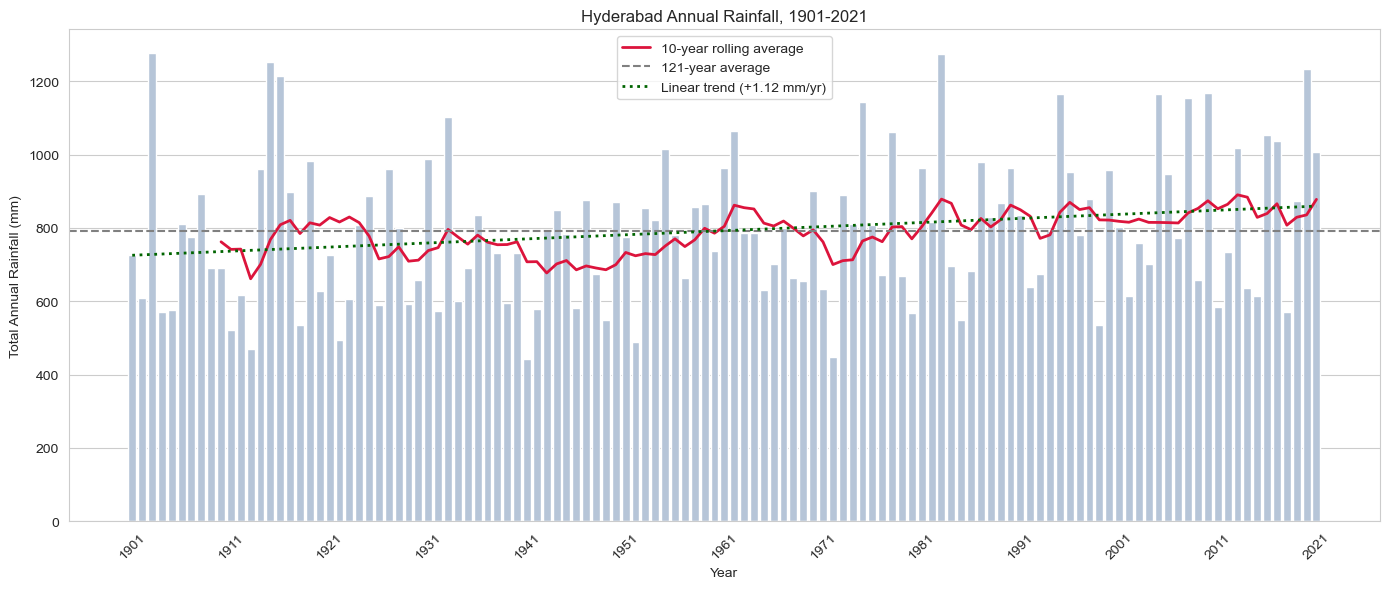

In [26]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("DataSets/Hyderabad Rainfall Dataset.csv")

# linear trend test - slope, significance, fit quality
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Year'], df['Total'])
print(f"Slope: {slope:.3f} mm/year | p-value: {p_value:.4f} | R-squared: {r_value**2:.4f}")

df['rolling_10yr'] = df['Total'].rolling(10).mean()

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14,6))
sns.barplot(x='Year', y='Total', data=df, color='lightsteelblue', ax=ax)
ax.plot(range(len(df)), df['rolling_10yr'], color='crimson', linewidth=2, label='10-year rolling average')
ax.axhline(df['Total'].mean(), color='gray', linestyle='--', label='121-year average')

trend_line = intercept + slope * df['Year']
ax.plot(range(len(df)), trend_line, color='darkgreen', linewidth=2, linestyle=':', label=f'Linear trend ({slope:+.2f} mm/yr)')

ax.set_xticks(range(0, len(df), 10))
ax.set_xticklabels(df['Year'][::10], rotation=45)
ax.set_xlabel('Year'); ax.set_ylabel('Total Annual Rainfall (mm)')
ax.set_title('Hyderabad Annual Rainfall, 1901-2021')
ax.legend()
plt.tight_layout()
plt.savefig('rainfall_trend_v2.png', dpi=120)
plt.show()

Trend coefficient (bookings change per month): 1149.493869315535
R-squared: 0.9272038576663603
        date  predicted_bookings
0 2024-03-01        54106.082881
1 2024-04-01       101293.642713
2 2024-05-01        98671.642713
3 2024-06-01       109401.142713
4 2024-07-01        70720.142713
5 2024-08-01        55647.642713


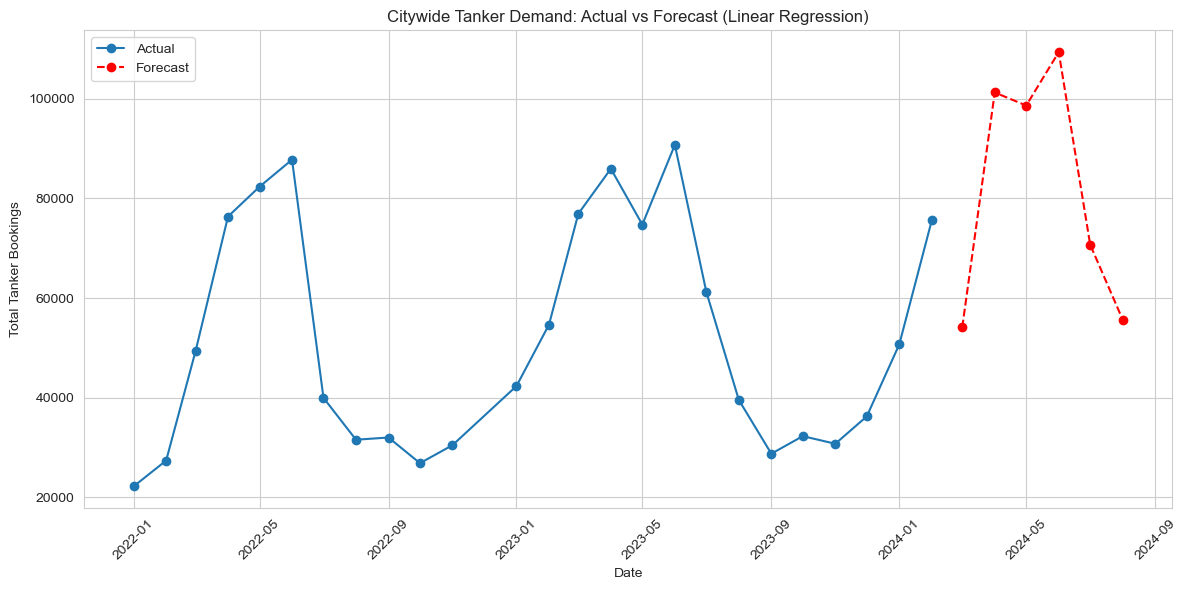

In [34]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

citywide = df.groupby(["year","month"])["noofbookings"].sum().reset_index()
citywide["date"] = pd.to_datetime(citywide["year"].astype(str) + "-" + citywide["month"].astype(str) + "-01")
citywide = citywide.sort_values("date").reset_index(drop=True)

# feature 1: time index - captures overall trend
citywide["time_index"] = range(len(citywide))

# feature 2: month dummies - captures seasonality (drop_first avoids redundancy)
month_dummies = pd.get_dummies(citywide["month"], prefix="month", drop_first=True)
X = pd.concat([citywide[["time_index"]], month_dummies], axis=1)
y = citywide["noofbookings"]

model = LinearRegression()
model.fit(X, y)

print("Trend coefficient (bookings change per month):", model.coef_[0])
print("R-squared:", model.score(X, y))

# build next 6 months to predict
last_date = citywide["date"].max()
future_dates = pd.date_range(last_date, periods=7, freq="MS")[1:]
future_df = pd.DataFrame({"date": future_dates})
future_df["month"] = future_df["date"].dt.month
future_df["time_index"] = range(len(citywide), len(citywide) + len(future_df))

future_month_dummies = pd.get_dummies(future_df["month"], prefix="month", drop_first=True)
future_month_dummies = future_month_dummies.reindex(columns=month_dummies.columns, fill_value=0)

X_future = pd.concat([future_df[["time_index"]], future_month_dummies], axis=1)
future_df["predicted_bookings"] = model.predict(X_future)

print(future_df[["date","predicted_bookings"]])

plt.figure(figsize=(12,6))
plt.plot(citywide["date"], citywide["noofbookings"], marker='o', label="Actual")
plt.plot(future_df["date"], future_df["predicted_bookings"], marker='o', linestyle='--', color='red', label="Forecast")
plt.xlabel("Date"); plt.ylabel("Total Tanker Bookings")
plt.title("Citywide Tanker Demand: Actual vs Forecast (Linear Regression)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("linreg_forecast.png", dpi=120)
plt.show()